In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/content/ncr_ride_bookings.csv')

In [3]:
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


### Column Descriptions:

*   **Date**: The date when the booking was made.
*   **Time**: The exact time when the booking was made.
*   **Booking ID**: A unique identifier for each ride booking.
*   **Booking Status**: The current status of the ride (e.g., 'Completed', 'Incomplete', 'No Driver Found').
*   **Customer ID**: A unique identifier for each customer.
*   **Vehicle Type**: The type of vehicle requested for the ride (e.g., 'eBike', 'Go Sedan', 'Auto', 'Premier Sedan', 'Bike').
*   **Pickup Location**: The geographical location where the ride started.
*   **Drop Location**: The geographical location where the ride was intended to end.
*   **Avg VTAT**: Average Vehicle Travel Time (likely in minutes/hours), representing the time taken for the vehicle to reach the pickup location.
*   **Avg CTAT**: Average Customer Travel Time (likely in minutes/hours), representing the total ride duration from pickup to drop-off.
*   **Reason for cancelling by Customer**: The reason provided by the customer if they cancelled the ride.
*   **Cancelled Rides by Driver**: Indicates if the driver cancelled the ride (1.0 for cancelled, NaN otherwise).
*   **Driver Cancellation Reason**: The reason provided by the driver if they cancelled the ride.
*   **Incomplete Rides**: Indicates if the ride was incomplete (1.0 for incomplete, NaN otherwise).
*   **Incomplete Rides Reason**: The reason for the ride being incomplete.
*   **Booking Value**: The monetary value or cost of the booking.
*   **Ride Distance**: The total distance covered during the ride (likely in kilometers).
*   **Driver Ratings**: The rating given to the driver by the customer.
*   **Customer Rating**: The rating given to the customer by the driver.
*   **Payment Method**: The method used by the customer to pay for the ride (e.g., 'UPI', 'Debit Card').

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [5]:
df['Booking Status'].value_counts()

,count
Booking Status,
Completed,93000
Cancelled by Driver,27000
No Driver Found,10500
Cancelled by Customer,10500
Incomplete,9000


**DUPLICATED VALUES**

In [6]:
df['Booking ID'].duplicated().sum()

np.int64(1233)

In [7]:
df['Customer ID'].duplicated().sum()

np.int64(1212)

In [8]:
df.duplicated(subset=['Booking ID','Customer ID']).sum()

np.int64(0)

In [9]:
df[(df['Booking ID']=='"CNR1205744"') & (df['Customer ID']=='"CID5537003"')]

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
38642,2024-04-16,15:49:30,"""CNR1205744""",Cancelled by Customer,"""CID5537003""",eBike,Sushant Lok,Noida Sector 18,7.5,NaN,...,Driver is not moving towards pickup location,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df.isnull().sum()

,0
Date,0
Time,0
Booking ID,0
Booking Status,0
Customer ID,0
Vehicle Type,0
Pickup Location,0
Drop Location,0
Avg VTAT,10500
Avg CTAT,48000


**Cancellation By Customer**

In [11]:
customer_df=df[['Booking Status','Cancelled Rides by Customer',
'Reason for cancelling by Customer']].dropna()
customer_df.head(5)

,Booking Status,Cancelled Rides by Customer,Reason for cancelling by Customer
18,Cancelled by Customer,1.0,Driver is not moving towards pickup location
39,Cancelled by Customer,1.0,Driver is not moving towards pickup location
46,Cancelled by Customer,1.0,Driver asked to cancel
62,Cancelled by Customer,1.0,Driver is not moving towards pickup location
78,Cancelled by Customer,1.0,Driver asked to cancel


In [12]:
customer_df['Reason for cancelling by Customer'].value_counts()

,count
Reason for cancelling by Customer,
Wrong Address,2362
Change of plans,2353
Driver is not moving towards pickup location,2335
Driver asked to cancel,2295
AC is not working,1155


In [13]:
customer_df.count()

,0
Booking Status,10500
Cancelled Rides by Customer,10500
Reason for cancelling by Customer,10500


In [14]:
driver_df=df[['Booking Status','Cancelled Rides by Driver',
'Driver Cancellation Reason']].dropna()
driver_df.head(5)

,Booking Status,Cancelled Rides by Driver,Driver Cancellation Reason
12,Cancelled by Driver,1.0,Personal & Car related issues
17,Cancelled by Driver,1.0,Customer related issue
19,Cancelled by Driver,1.0,Customer related issue
26,Cancelled by Driver,1.0,Personal & Car related issues
30,Cancelled by Driver,1.0,More than permitted people in there


In [15]:
driver_df['Driver Cancellation Reason'].value_counts()

,count
Driver Cancellation Reason,
Customer related issue,6837
The customer was coughing/sick,6751
Personal & Car related issues,6726
More than permitted people in there,6686


In [16]:
driver_df.count()

,0
Booking Status,27000
Cancelled Rides by Driver,27000
Driver Cancellation Reason,27000


driver cancellation 27000+123000(null)

customer cancellation 10500+139000(null)

incomp rides 9000+141000(null)

successful rides 93000+57000(null)

 (booking value,payment method,ride dist) 103000(completed+incompletd) ride

 driver and customer ratings are for both complete and incomp rides as there are 93000+57


In [17]:
incomp_rides_df=df[['Booking Status','Incomplete Rides',
'Incomplete Rides Reason']].dropna()
incomp_rides_df.head(5)

,Booking Status,Incomplete Rides,Incomplete Rides Reason
1,Incomplete,1.0,Vehicle Breakdown
9,Incomplete,1.0,Other Issue
28,Incomplete,1.0,Vehicle Breakdown
42,Incomplete,1.0,Other Issue
47,Incomplete,1.0,Vehicle Breakdown


In [18]:
incomp_rides_df['Incomplete Rides Reason'].value_counts()

,count
Incomplete Rides Reason,
Customer Demand,3040
Vehicle Breakdown,3012
Other Issue,2948


In [19]:
incomp_rides_df.count()

,0
Booking Status,9000
Incomplete Rides,9000
Incomplete Rides Reason,9000


In [20]:
booking_df=df[['Booking Status','Booking Value','Ride Distance','Payment Method']].dropna()
booking_df.head(5)

,Booking Status,Booking Value,Ride Distance,Payment Method
1,Incomplete,237.0,5.73,UPI
2,Completed,627.0,13.58,Debit Card
3,Completed,416.0,34.02,UPI
4,Completed,737.0,48.21,UPI
5,Completed,316.0,4.85,UPI


In [21]:
booking_df['Booking Status'].value_counts()

,count
Booking Status,
Completed,93000
Incomplete,9000


In [22]:
booking_df.count()

,0
Booking Status,102000
Booking Value,102000
Ride Distance,102000
Payment Method,102000


Avg VTAT,CTAT

In [23]:
temp_df=df[['Booking Status','Avg VTAT','Avg CTAT']].dropna()
temp_df.head(5)

,Booking Status,Avg VTAT,Avg CTAT
1,Incomplete,4.9,14.0
2,Completed,13.4,25.8
3,Completed,13.1,28.5
4,Completed,5.3,19.6
5,Completed,5.1,18.1


In [24]:
temp_df['Booking Status'].value_counts()

,count
Booking Status,
Completed,93000
Incomplete,9000


In [25]:
temp_df.count()

,0
Booking Status,102000
Avg VTAT,102000
Avg CTAT,102000


In [26]:
temp_df['Avg CTAT'].isnull().sum()

np.int64(0)

In [27]:
temp_df['Avg CTAT'].describe()

,Avg CTAT
count,102000.000000
mean,29.149636
std,8.902577
min,10.000000
25%,21.600000
50%,28.800000
75%,36.800000
max,45.000000


In [28]:
temp_df['Avg VTAT'].describe()

,Avg VTAT
count,102000.000000
mean,8.291455
std,3.712160
min,2.000000
25%,5.100000
50%,8.200000
75%,11.400000
max,15.000000


drop columns 'Cancelled Rides by Customer','Cancelled Rides by Driver' and 'Incomplete Rides'

In [29]:
df.drop(columns=['Cancelled Rides by Customer','Cancelled Rides by Driver'],inplace=True)

In [30]:
df.drop(columns=['Incomplete Rides'],inplace=True)

In [31]:
df.sample(3)

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Reason for cancelling by Customer,Driver Cancellation Reason,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
48054,2024-06-29,16:54:49,"""CNR5248691""",Incomplete,"""CID9201018""",Bike,Chanakyapuri,Vidhan Sabha,4.1,20.1,NaN,NaN,Other Issue,1010.0,10.88,NaN,NaN,Debit Card
78976,2024-03-24,17:06:29,"""CNR4456486""",Completed,"""CID2877464""",eBike,Govindpuri,Sadar Bazar Gurgaon,7.0,21.9,NaN,NaN,NaN,452.0,42.26,4.5,5.0,UPI
31616,2024-08-03,14:05:57,"""CNR1469709""",Completed,"""CID1280631""",Auto,Malviya Nagar,Seelampur,4.9,38.1,NaN,NaN,NaN,302.0,46.83,4.1,4.7,Debit Card


**FEATURE ENG**

In [32]:
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d', errors='coerce')
df['Month'] = df['Date'].dt.strftime('%b')
display(df.head())

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Reason for cancelling by Customer,Driver Cancellation Reason,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Month
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mar
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,Nov
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card,Aug
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI,Oct
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI,Sep


In [33]:
if 'Month' in df.columns:
    month_col = df['Month']
    df = df.drop(columns=['Month']) # Drop the existing 'Month' column
    df.insert(1, 'Month', month_col) # Insert 'Month' at index 1
else:
    print("'Month' column not found. Please ensure it has been created.")
display(df.head())

,Date,Month,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Reason for cancelling by Customer,Driver Cancellation Reason,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,Mar,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,Nov,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,Aug,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,Oct,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,Sep,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [34]:
df['Day'] = df['Date'].dt.day_name()

# Reorder columns to place 'Day' after 'Month'
if 'Day' in df.columns:
    day_col = df['Day']
    df = df.drop(columns=['Day']) # Drop the existing 'Day' column
    df.insert(2, 'Day', day_col) # Insert 'Day' at index 2 (after Date and Month)
else:
    print("'Day' column not found. Please ensure it has been created.")

In [35]:
display(df.head())

,Date,Month,Day,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Reason for cancelling by Customer,Driver Cancellation Reason,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,Mar,Saturday,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,Nov,Friday,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,Aug,Friday,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,Oct,Monday,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,Sep,Monday,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


*peak and non-peak hours*

PEAK= 1

NON-PEAK = 0

In [36]:
df['Time']=pd.to_datetime(df['Time']).dt.time

/tmp/ipykernel_945/3143423362.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time']=pd.to_datetime(df['Time']).dt.time


In [37]:
from datetime import time


def is_peak(Time,Day):
 if pd.isna(Time):
  return 0;
 if((time(8,0) <Time and Time<time(10,30)) or (time(17,0) <=Time and Time <= time(20,0)) ):
  return 1;

 elif(Day in ['Saturday','Sunday'] and (time(20,0) <Time and Time < time(2,0))):
  return 1;
 else:
  return 0;

In [38]:
df['peak'] = df.apply(lambda row: is_peak(row['Time'], row['Day']), axis=1)

In [39]:
if 'peak' in df.columns:
    peak_col = df['peak']
    df=df.drop(columns=['peak'])
    df.insert(4, 'peak', peak_col)

display(df.head())

,Date,Month,Day,Time,peak,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,...,Avg VTAT,Avg CTAT,Reason for cancelling by Customer,Driver Cancellation Reason,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,Mar,Saturday,12:29:38,0,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,Nov,Friday,18:01:39,1,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,...,4.9,14.0,NaN,NaN,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,Aug,Friday,08:56:10,1,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,...,13.4,25.8,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,Oct,Monday,17:17:25,1,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,...,13.1,28.5,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,Sep,Monday,22:08:00,0,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,...,5.3,19.6,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


**EDA**

### Column Classification

Based on the data types and typical content, the columns can be classified as follows:

**Numerical Columns:**
*   `Avg VTAT`
*   `Avg CTAT`
*   `Booking Value`
*   `Ride Distance`
*   `Driver Ratings`
*   `Customer Rating`

**Categorical Columns:**
*   `Booking Status`
*   `Vehicle Type`
*   `Payment Method`
*   `Reason for cancelling by Customer`
*   `Driver Cancellation Reason`
*   `Incomplete Rides Reason`

**Mixed/Identifier/Text Columns:**
(These columns are typically `object` type and might require specific parsing or feature engineering for analysis, or they serve as unique identifiers or free-form text.)
*   `Date`
*   `Time`
*   `Booking ID`
*   `Customer ID`
*   `Pickup Location`
*   `Drop Location`

**UNIVARIATE ANALYSIS ON CATEGORICAL COLUMNS**

In [40]:
## Vehicle Type
vehicle_type_counts = df['Vehicle Type'].value_counts()
vehicle_type_percentage = df['Vehicle Type'].value_counts(normalize=True) * 100

vehicle_type_df = pd.DataFrame({
    'Count': vehicle_type_counts,
    'Percentage': vehicle_type_percentage
})
display(vehicle_type_df)
print(f"Total Vehicle Type Entries: {vehicle_type_counts.sum()}")

,Count,Percentage
Vehicle Type,,
Auto,37419,24.946000
Go Mini,29806,19.870667
Go Sedan,27141,18.094000
Bike,22517,15.011333
Premier Sedan,18111,12.074000
eBike,10557,7.038000
Uber XL,4449,2.966000


Total Vehicle Type Entries: 150000


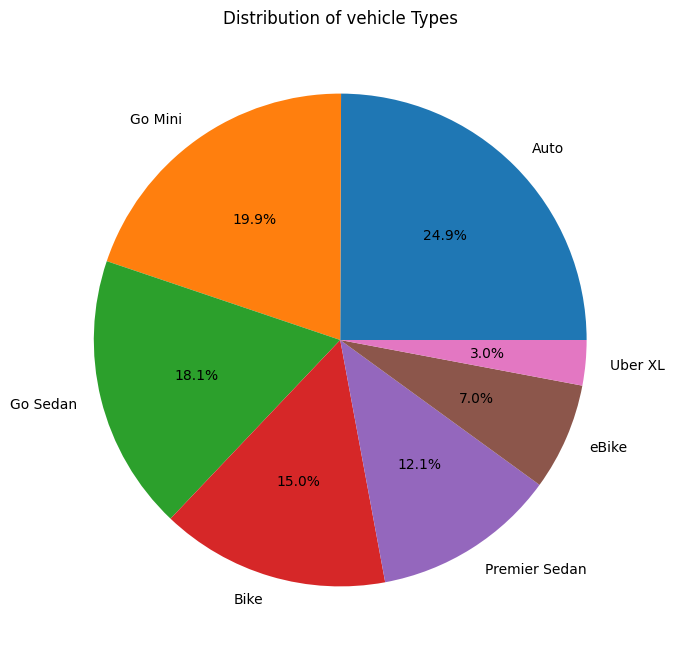

In [41]:
plt.figure(figsize=(8,8))
vehicle_type_counts.plot(kind='pie',autopct='%1.1f%%')
plt.title('Distribution of vehicle Types')
plt.ylabel('')
plt.show()

**CONCLUSION**: *around 25% people of Delhi-NCR rides by Auto followed by Go Mini*

NOT ANY NULL VALUE

In [42]:
## Payment Method
payment_method_counts = df['Payment Method'].value_counts()
payment_method_percent= df['Payment Method'].value_counts(normalize=True) * 100
payment_method_df=pd.DataFrame({
    'count':payment_method_counts,
    'percentage':payment_method_percent
})
display(payment_method_df)

print(f'Total Payments: {payment_method_counts.sum()}')

,count,percentage
Payment Method,,
UPI,45909,45.008824
Cash,25367,24.869608
Uber Wallet,12276,12.035294
Credit Card,10209,10.008824
Debit Card,8239,8.077451


Total Payments: 102000


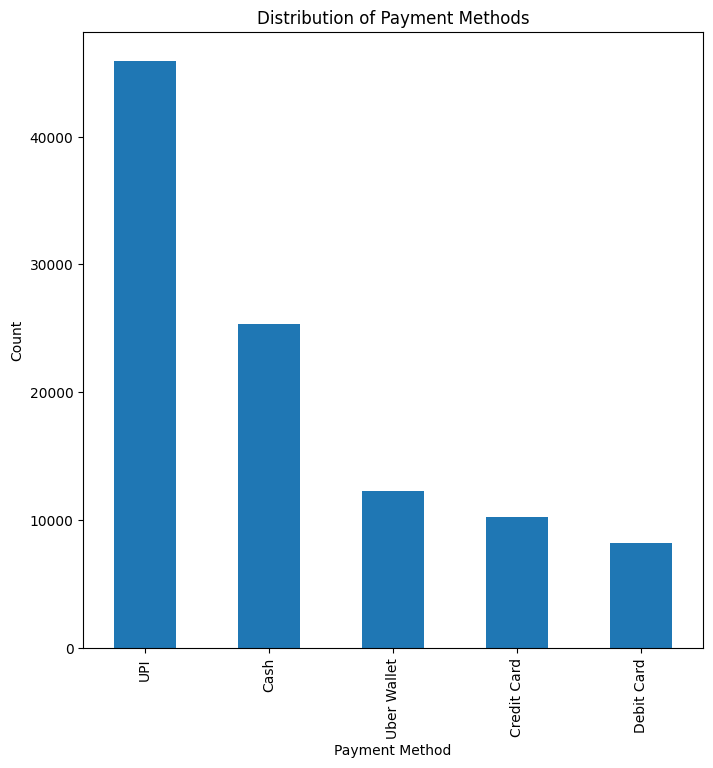

In [43]:
plt.figure(figsize=(8,8))
payment_method_counts.plot(kind='bar')
plt.ylabel('Count')
plt.title('Distribution of Payment Methods')
plt.show()

**CONCLUSION**:*UPI is the most popular payment method at 45%, followed by Cash at 24.87%. This indicates a strong preference for digital payments, with cash remaining a significant secondary option.*

---





In [44]:
## Booking Status
booking_status_counts = df['Booking Status'].value_counts()
booking_status_percent= df['Booking Status'].value_counts(normalize=True) * 100
booking_status_df=pd.DataFrame({
    'count':booking_status_counts,
    'percentage':booking_status_percent})
display(booking_status_df)

,count,percentage
Booking Status,,
Completed,93000,62.0
Cancelled by Driver,27000,18.0
No Driver Found,10500,7.0
Cancelled by Customer,10500,7.0
Incomplete,9000,6.0


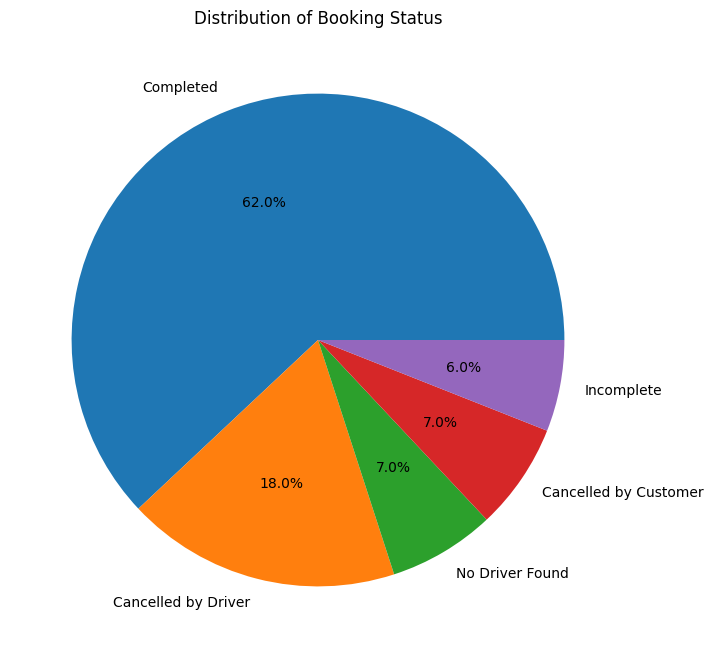

In [45]:
plt.figure(figsize=(8,8))
booking_status_counts.plot(kind='pie',autopct='%1.1f%%')
plt.ylabel('')
plt.title('Distribution of Booking Status')
plt.show()

**CONCLUSION**:*62% ride completion rate is a solid foundation. However, the significant 32% of bookings lost due to cancellations (driver/customer) or no driver availability presents a critical area for improvement.*





In [46]:
df['Pickup Location'].nunique()

176

In [47]:
df['Drop Location'].nunique()

176

**UNIVARIATE ANALYSIS ON NUMERICAL
COLUMNS**

---



In [48]:
## Customer Rating
df['Customer Rating'].describe()

,Customer Rating
count,93000.000000
mean,4.404584
std,0.437819
min,3.000000
25%,4.200000
50%,4.500000
75%,4.800000
max,5.000000


<Axes: ylabel='Customer Rating'>

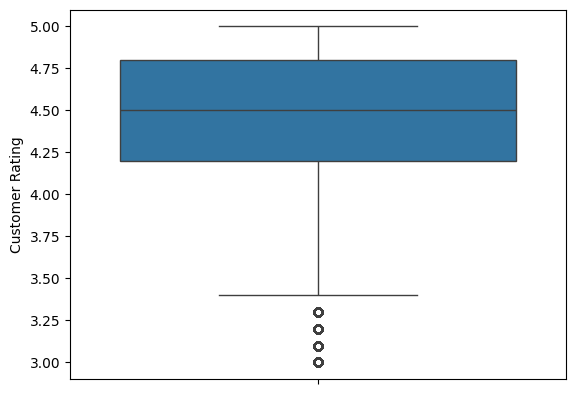

In [49]:
sns.boxplot(df['Customer Rating'])

In [50]:
## Driver Rating
df['Driver Ratings'].describe()

,Driver Ratings
count,93000.000000
mean,4.230992
std,0.436871
min,3.000000
25%,4.100000
50%,4.300000
75%,4.600000
max,5.000000


<Axes: ylabel='Driver Ratings'>

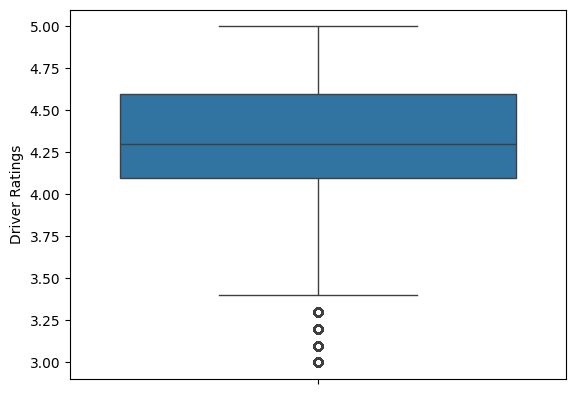

In [51]:
sns.boxplot(df['Driver Ratings'])

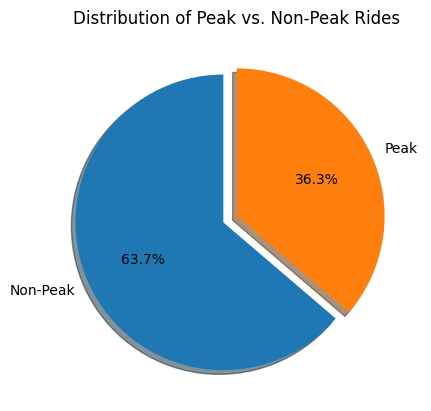

In [52]:
peak_col = df['peak'].value_counts()
labels = ['Non-Peak', 'Peak'] # Assuming 0 is Non-Peak and 1 is Peak based on previous output
explode = (0.1, 0) # Explode the 'Non-Peak' slice slightly for emphasis

plt.pie(peak_col, autopct='%1.1f%%', labels=labels, explode=explode, shadow=True, startangle=90)
plt.title('Distribution of Peak vs. Non-Peak Rides')
plt.ylabel('')
plt.show()

In [53]:
peak_col

,count
peak,
0,95609
1,54391


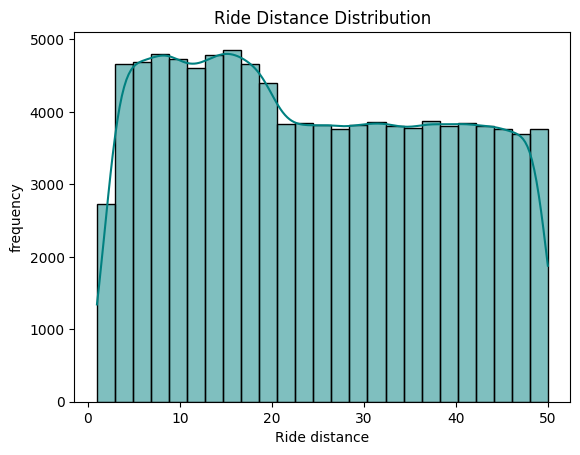

In [54]:
sns.histplot(
    data=df,
    x='Ride Distance',
    bins=25,
    kde=True,
    color='teal'
)

plt.xlabel('Ride distance')
plt.ylabel('frequency')
plt.title('Ride Distance Distribution')
plt.show()

/tmp/ipykernel_945/4062769924.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_bookings.index, y=hourly_bookings.values, palette='viridis')


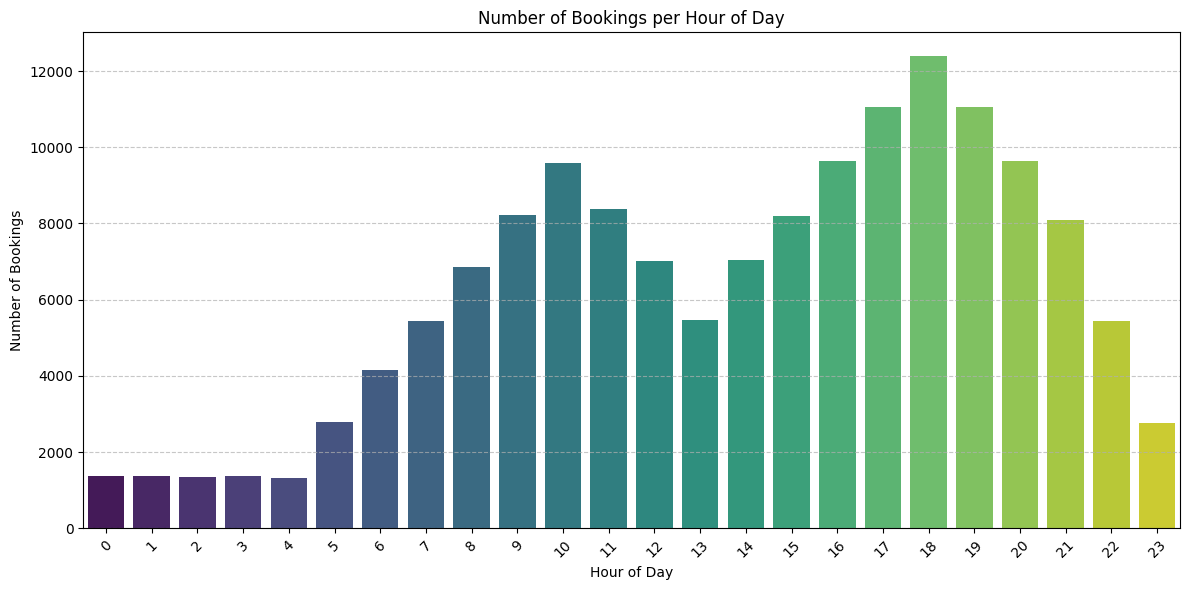

In [55]:
## NO. OF BOOKING PER HOUR

df['Hour'] = df['Time'].apply(lambda x: x.hour)

hourly_bookings = df['Hour'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.barplot(x=hourly_bookings.index, y=hourly_bookings.values, palette='viridis')
plt.title('Number of Bookings per Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **BIVARIATE ANALYSIS**


---




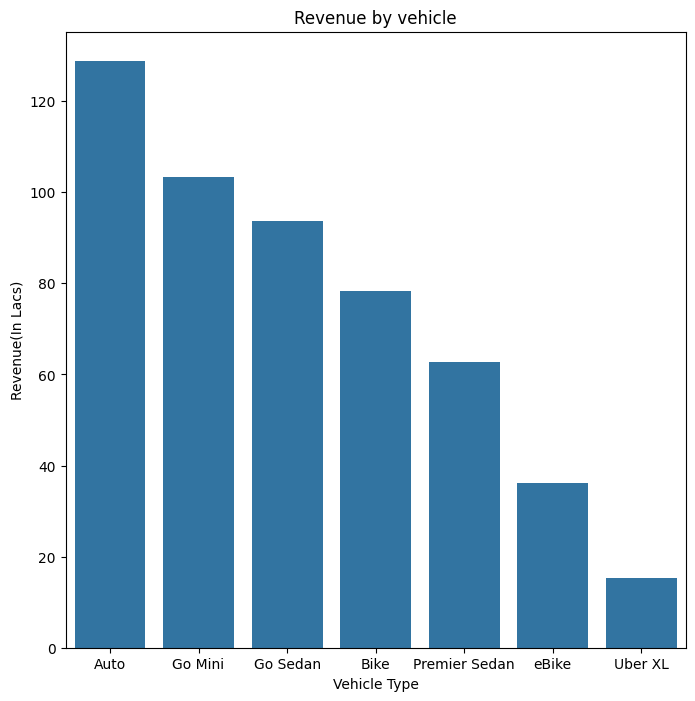

In [56]:
plt.figure(figsize=(8,8))
total_revenue=df.groupby('Vehicle Type').agg({'Booking Value':'sum'}).sort_values(by='Booking Value',ascending=False)
total_revenue['Booking Value']=total_revenue['Booking Value']/100000

sns.barplot(data=total_revenue,x='Vehicle Type',y='Booking Value')
plt.xlabel('Vehicle Type')
plt.ylabel('Revenue(In Lacs)')
plt.title('Revenue by vehicle')
plt.show()

**CONCLUSION**: *Go Mini vehicles generate the highest revenue, closely followed by Premier Sedan and Auto. This indicates strong demand or higher average booking values for these vehicle types. eBike and Bike generate comparatively lower revenue.*

In [57]:
total_revenue

,Booking Value
Vehicle Type,
Auto,128.78422
Go Mini,103.38496
Go Sedan,93.69719
Bike,78.37697
Premier Sedan,62.75332
eBike,36.18485
Uber XL,15.28032


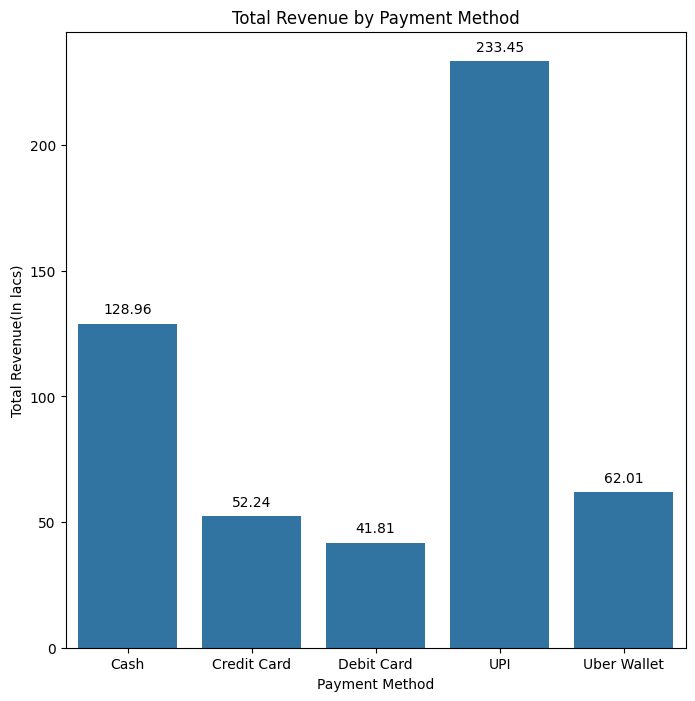

In [58]:
plt.figure(figsize=(8,8))
revenue_by_payment_method =df.groupby('Payment Method').agg({'Booking Value':'sum'})
revenue_by_payment_method['Booking Value']=revenue_by_payment_method['Booking Value']/100000
ax = sns.barplot(data=revenue_by_payment_method, x='Payment Method', y='Booking Value')
plt.xlabel('Payment Method')
plt.ylabel('Total Revenue(In lacs)')
plt.title('Total Revenue by Payment Method')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()

/tmp/ipykernel_945/2154360314.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_by_distance_bin = df.groupby('Ride Distance Bin')['Booking Value'].sum().reset_index()


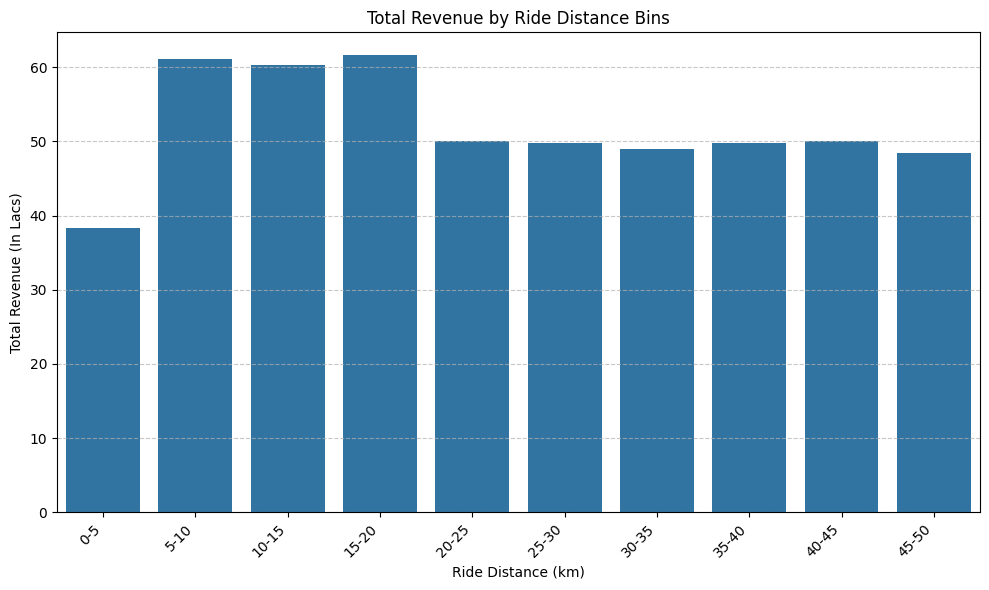

In [59]:
## TOTAL REVENUE BY RIDE DISTANCE
bins = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
labels = [f'{i}-{j}' for i, j in zip(bins[:-1], bins[1:])]
df['Ride Distance Bin'] = pd.cut(df['Ride Distance'], bins=bins, labels=labels, right=False)

revenue_by_distance_bin = df.groupby('Ride Distance Bin')['Booking Value'].sum().reset_index()
revenue_by_distance_bin['Booking Value'] = revenue_by_distance_bin['Booking Value'] / 100000

plt.figure(figsize=(10, 6))
sns.barplot(x='Ride Distance Bin', y='Booking Value', data=revenue_by_distance_bin)
plt.xlabel('Ride Distance (km)')
plt.ylabel('Total Revenue (In Lacs)')
plt.title('Total Revenue by Ride Distance Bins')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_945/1204922423.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_by_month = df.groupby('Month').agg({'Booking Value':'sum'}).reset_index()


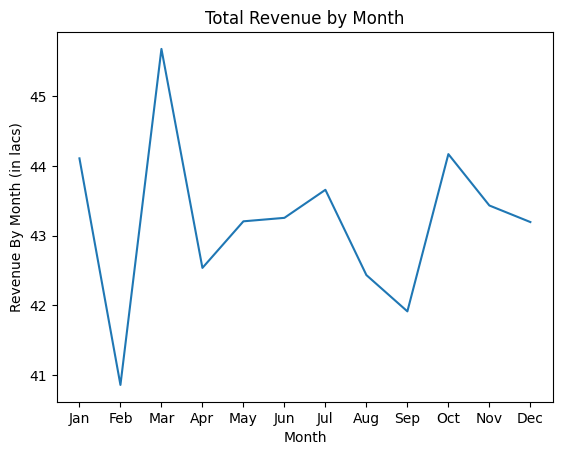

In [60]:
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

revenue_by_month = df.groupby('Month').agg({'Booking Value':'sum'}).reset_index()
revenue_by_month['Booking Value'] = revenue_by_month['Booking Value']/100000

sns.lineplot(data=revenue_by_month, x='Month', y='Booking Value')
plt.xlabel('Month')
plt.ylabel('Revenue By Month (in lacs)')
plt.title('Total Revenue by Month')
plt.show()

/tmp/ipykernel_945/2888722336.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_by_Day = df.groupby('Day').agg({'Booking Value':'sum'}).reset_index()


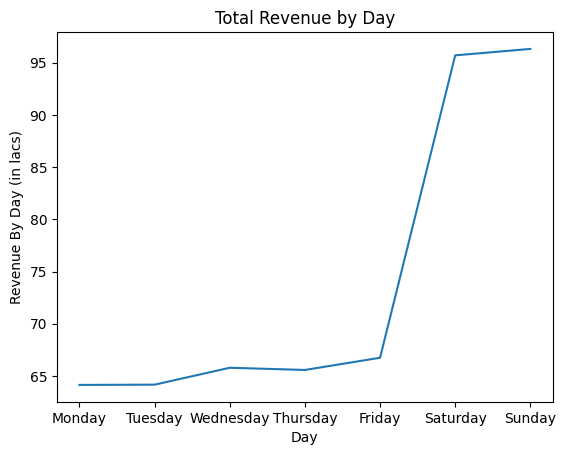

In [61]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['Day'] = pd.Categorical(df['Day'], categories=day_order, ordered=True)

revenue_by_Day = df.groupby('Day').agg({'Booking Value':'sum'}).reset_index()
revenue_by_Day['Booking Value'] = revenue_by_Day['Booking Value']/100000

sns.lineplot(data=revenue_by_Day, x='Day', y='Booking Value')
plt.xlabel('Day')
plt.ylabel('Revenue By Day (in lacs)')
plt.title('Total Revenue by Day')
plt.show()

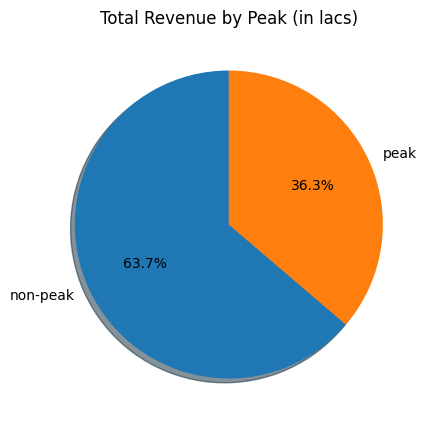

,Booking Value
peak,
0,330.49144
1,187.97039


In [62]:
revenue_by_peak=df.groupby('peak').agg({'Booking Value':'sum'})
revenue_by_peak['Booking Value'] = revenue_by_peak['Booking Value']/100000
labels=['non-peak','peak']
plt.figure(figsize=(8,5))
plt.pie(revenue_by_peak['Booking Value'],autopct='%1.1f%%',labels=labels,shadow=True,startangle=90)
plt.title('Total Revenue by Peak (in lacs)')
plt.show()
display(revenue_by_peak)

In [63]:
## TOP 10 PICKUP LOCATIONS
revenue_by_pickup=df.groupby('Pickup Location').agg({'Booking Value':'sum'}).sort_values(by='Booking Value',ascending=False).head(10)
revenue_by_pickup['Booking Value']=revenue_by_pickup['Booking Value']/100000
revenue_by_pickup

,Booking Value
Pickup Location,
Barakhamba Road,3.41154
Khandsa,3.38502
Subhash Chowk,3.29386
Pataudi Chowk,3.28572
Badarpur,3.27193
Tughlakabad,3.26283
AIIMS,3.25733
Inderlok,3.25358
Mayur Vihar,3.22409


<Figure size 800x500 with 0 Axes>

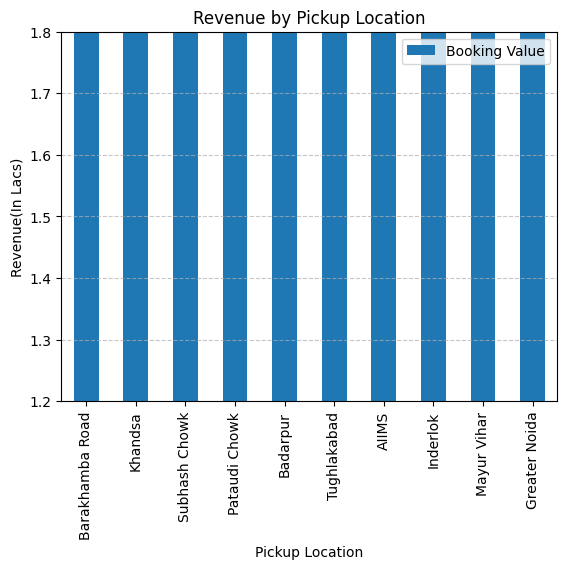

In [64]:
plt.figure(figsize=(8,5))
revenue_by_pickup.plot(kind='bar')
plt.xlabel('Pickup Location')
plt.ylabel('Revenue(In Lacs)')
plt.ylim(1.2,1.8)
plt.title('Revenue by Pickup Location')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [65]:
## lowest revenue
revenue_by_pickup_lowest=df.groupby('Pickup Location').agg({'Booking Value':'sum'}).sort_values(by='Booking Value',ascending=False).tail(15).sort_values(by='Booking Value',ascending=True)
revenue_by_pickup_lowest['Booking Value']=revenue_by_pickup_lowest['Booking Value']/100000
revenue_by_pickup_lowest

,Booking Value
Pickup Location,
Vinobapuri,2.53208
Vatika Chowk,2.53751
Akshardham,2.58535
Faridabad Sector 15,2.59277
Old Gurgaon,2.64679
Netaji Subhash Place,2.66297
Chhatarpur,2.67032
Chirag Delhi,2.68565
Ghitorni Village,2.68667


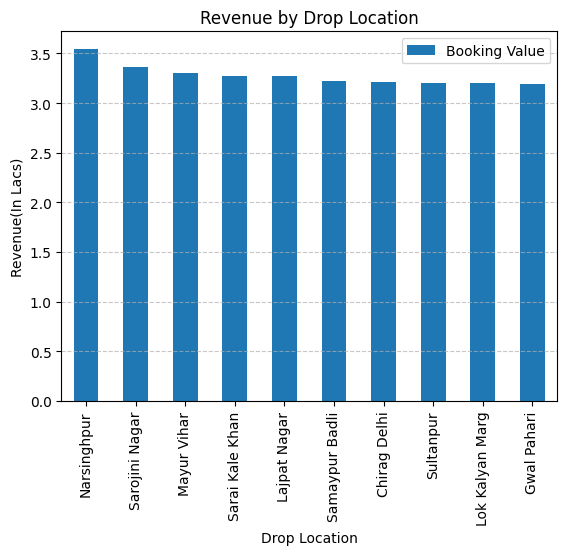

In [66]:
### TOP 10 DROP LOCATIONS

revenue_by_Drop=df.groupby('Drop Location').agg({'Booking Value':'sum'}).sort_values(by='Booking Value',ascending=False).head(10)
revenue_by_Drop['Booking Value']=revenue_by_Drop['Booking Value']/100000
revenue_by_Drop.plot(kind='bar')
plt.xlabel('Drop Location')
plt.ylabel('Revenue(In Lacs)')
plt.title('Revenue by Drop Location')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


<Figure size 1200x1000 with 0 Axes>

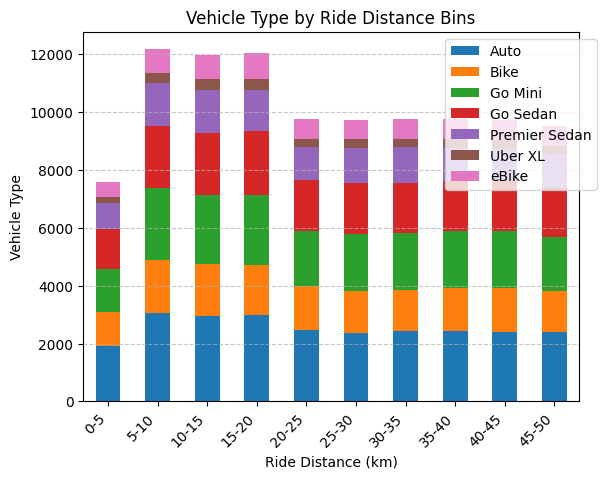

In [67]:
bins = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
labels = [f'{i}-{j}' for i, j in zip(bins[:-1], bins[1:])]
df['Ride Distance Bin'] = pd.cut(df['Ride Distance'], bins=bins, labels=labels, right=False)

plt.figure(figsize=(12,10))
pd.crosstab( df['Ride Distance Bin'],df['Vehicle Type']).plot(kind='bar', stacked=True)
plt.xlabel('Ride Distance (km)')
plt.ylabel('Vehicle Type')
plt.title('Vehicle Type by Ride Distance Bins')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper right')
plt.show()

<Figure size 1200x1000 with 0 Axes>

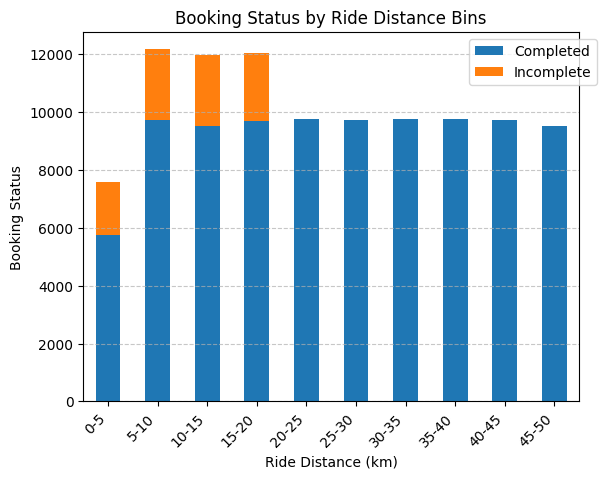

In [68]:

plt.figure(figsize=(12,10))
pd.crosstab( df['Ride Distance Bin'],df['Booking Status']).plot(kind='bar', stacked=True)
plt.xlabel('Ride Distance (km)')
plt.ylabel('Booking Status')
plt.title('Booking Status by Ride Distance Bins')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper right')
plt.show()

**Customer Segmentation**

---


In [69]:
cust_segment=df.groupby('Customer ID').agg({'Booking Value':'sum','Booking ID':'count'}).sort_values(by='Booking Value',ascending=False)
cust_segment

,Booking Value,Booking ID
Customer ID,,
"""CID2674107""",4987.0,2
"""CID7828101""",4722.0,3
"""CID2706299""",4277.0,1
"""CID4843078""",4228.0,1
"""CID2978596""",4220.0,1
...,...,...
"""CID3826775""",0.0,1
"""CID3826942""",0.0,1
"""CID3827087""",0.0,1


In [70]:
cust_segment[(cust_segment['Booking ID'] > 1) & (cust_segment['Booking Value'] != 0)]

,Booking Value,Booking ID
Customer ID,,
"""CID2674107""",4987.0,2
"""CID7828101""",4722.0,3
"""CID9920842""",3867.0,2
"""CID1171769""",3673.0,2
"""CID9285388""",3486.0,2
...,...,...
"""CID7937963""",55.0,2
"""CID2025424""",55.0,2
"""CID7382505""",53.0,2


In [71]:
df['Customer ID'].nunique()

148788

237 customers from 67512 who booked more than once
## *215 are ones who booked more than once having booking status as completed or incomplete(not cancelled one)*

In [72]:
## TOP 15 CUSTOMERS REVENUE
cust_segment.head(15)

,Booking Value,Booking ID
Customer ID,,
"""CID2674107""",4987.0,2
"""CID7828101""",4722.0,3
"""CID2706299""",4277.0,1
"""CID4843078""",4228.0,1
"""CID2978596""",4220.0,1
"""CID5235759""",4202.0,1
"""CID5789715""",4133.0,1
"""CID9539119""",4109.0,1
"""CID1753183""",4088.0,1


# CANCELLATION

---



<Figure size 1400x700 with 0 Axes>

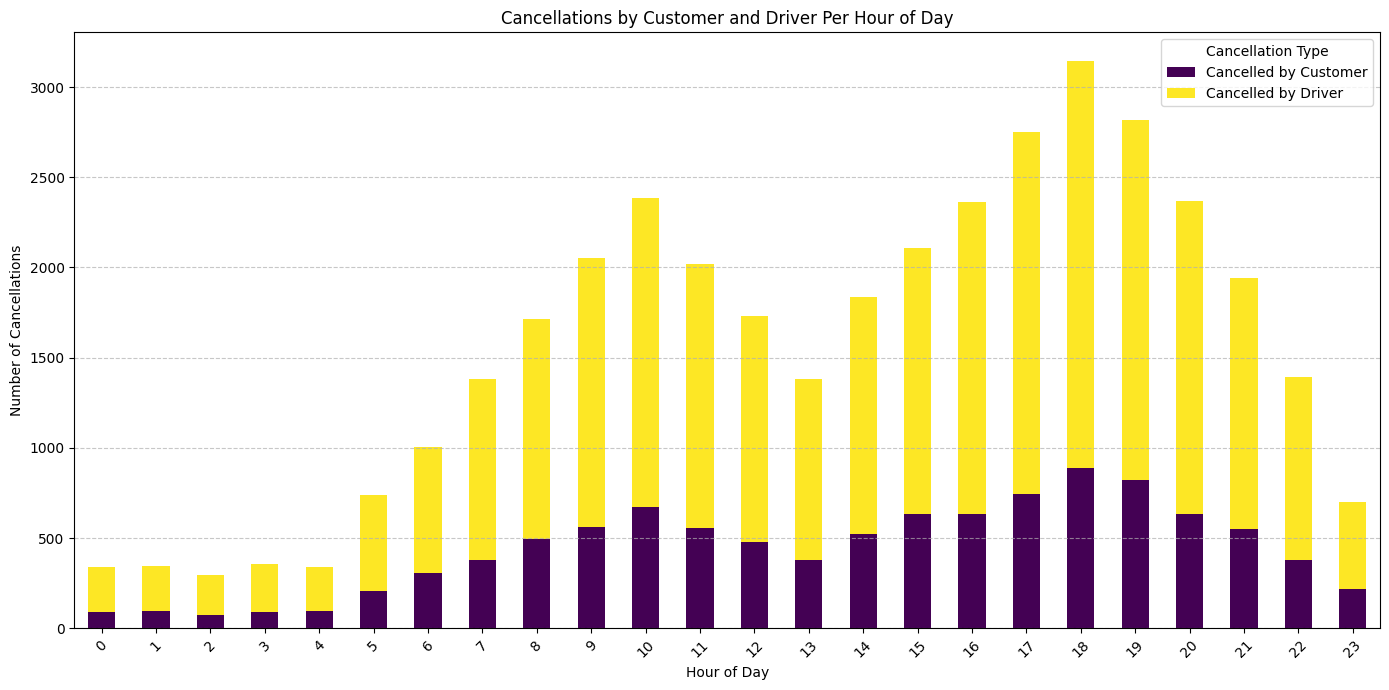

In [73]:
# Extract the hour from the 'Time' column
df['Hour'] = df['Time'].apply(lambda x: x.hour)

# Filter for cancellation data (customer and driver)
cancellation_data = df[df['Booking Status'].isin(['Cancelled by Customer', 'Cancelled by Driver'])]

# Group by hour and booking status, then count bookings
cancellations_per_hour = cancellation_data.groupby(['Hour', 'Booking Status']).size().unstack(fill_value=0)

# Plotting the stacked bar chart
plt.figure(figsize=(14, 7))
cancellations_per_hour.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='viridis')

plt.title('Cancellations by Customer and Driver Per Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Cancellations')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Cancellation Type')
plt.tight_layout()
plt.show()

/tmp/ipykernel_945/1853573084.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cancellations_per_day = cancellation_data.groupby(['Day', 'Booking Status']).size().unstack(fill_value=0)


<Figure size 1400x700 with 0 Axes>

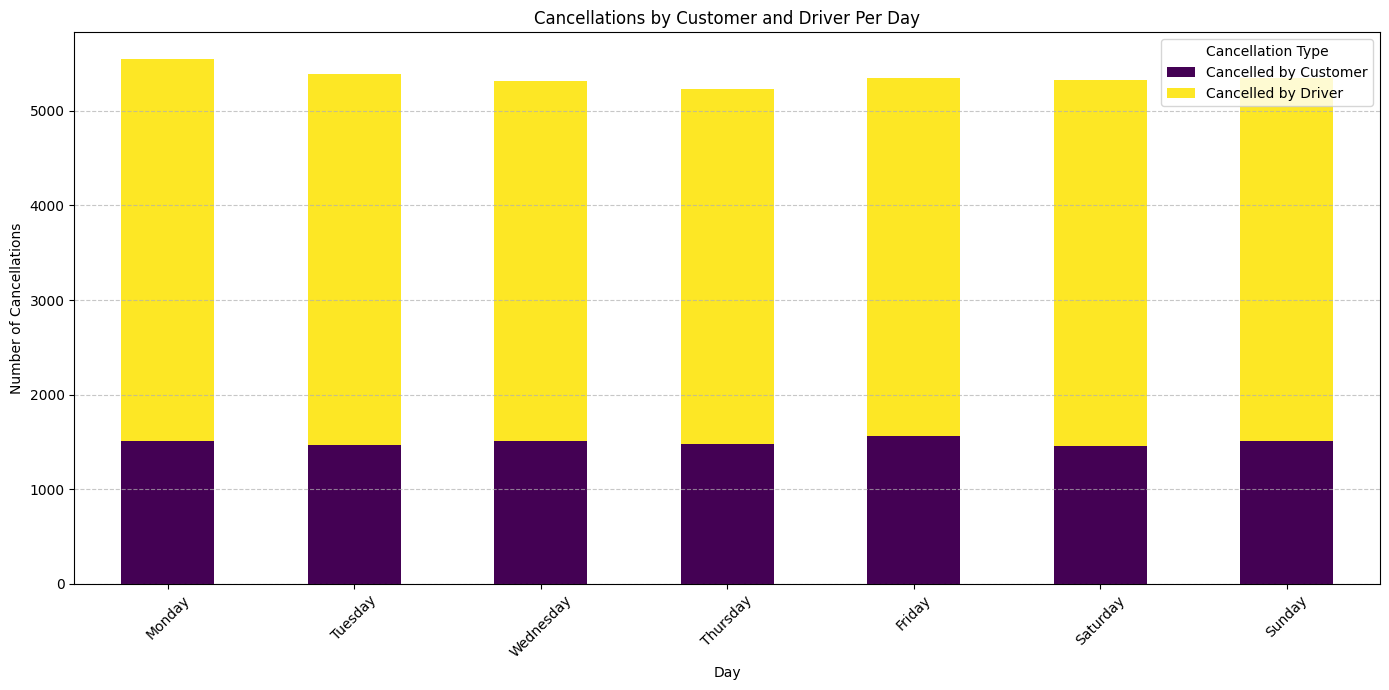

In [74]:
# Filter for cancellation data (customer and driver)
cancellation_data = df[df['Booking Status'].isin(['Cancelled by Customer', 'Cancelled by Driver'])]

# Group by day and booking status, then count bookings
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['Day'] = pd.Categorical(df['Day'], categories=day_order, ordered=True)
cancellations_per_day = cancellation_data.groupby(['Day', 'Booking Status']).size().unstack(fill_value=0)

# Plotting the stacked bar chart
plt.figure(figsize=(14, 7))
cancellations_per_day.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='viridis')

plt.title('Cancellations by Customer and Driver Per Day')
plt.xlabel('Day')
plt.ylabel('Number of Cancellations')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Cancellation Type')
plt.tight_layout()
plt.show()

In [75]:
df[df['Booking Status'].isin(['Cancelled by Customer', 'Cancelled by Driver'])].head()


,Date,Month,Day,Time,peak,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,...,Reason for cancelling by Customer,Driver Cancellation Reason,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Hour,Ride Distance Bin
12,2024-06-25,Jun,Tuesday,22:44:15,0,"""CNR4386945""",Cancelled by Driver,"""CID5543520""",eBike,Patel Chowk,...,NaN,Personal & Car related issues,NaN,NaN,NaN,NaN,NaN,NaN,22,NaN
17,2024-12-15,Dec,Sunday,15:08:25,0,"""CNR6739317""",Cancelled by Driver,"""CID8682675""",Go Sedan,Vinobapuri,...,NaN,Customer related issue,NaN,NaN,NaN,NaN,NaN,NaN,15,NaN
18,2024-11-24,Nov,Sunday,09:07:10,1,"""CNR6126048""",Cancelled by Customer,"""CID1060329""",eBike,Kashmere Gate,...,Driver is not moving towards pickup location,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9,NaN
19,2024-05-24,May,Friday,19:53:57,1,"""CNR9465840""",Cancelled by Driver,"""CID9046501""",eBike,Pitampura,...,NaN,Customer related issue,NaN,NaN,NaN,NaN,NaN,NaN,19,NaN
26,2024-01-26,Jan,Friday,09:44:00,1,"""CNR3614535""",Cancelled by Driver,"""CID2507102""",Auto,Cyber Hub,...,NaN,Personal & Car related issues,NaN,NaN,NaN,NaN,NaN,NaN,9,NaN


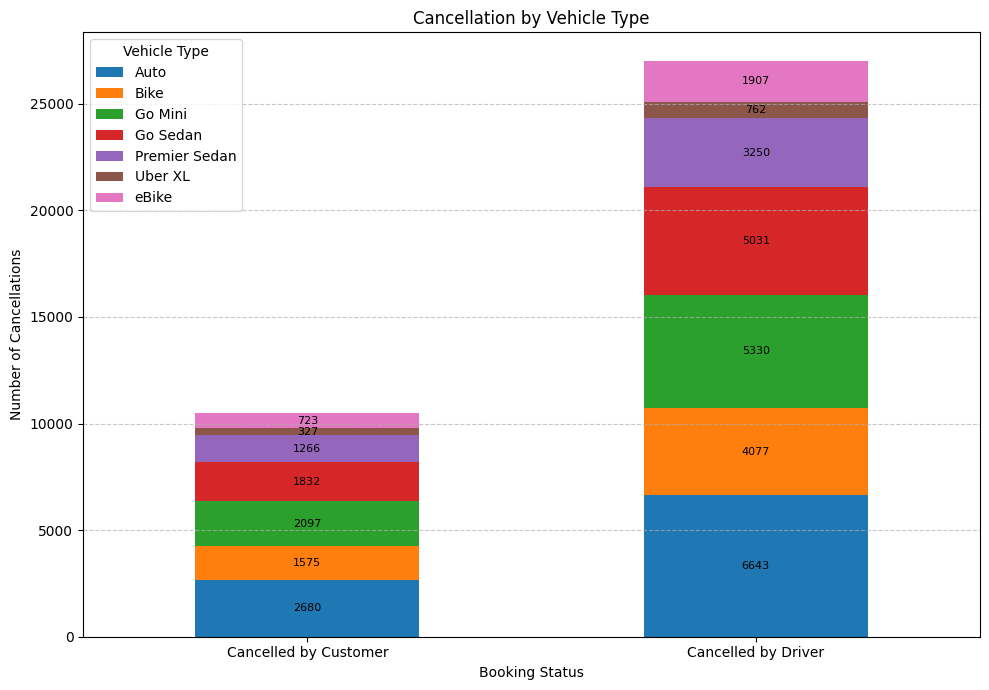

In [76]:
plt.figure(figsize=(10, 7))
crosstab_df = pd.crosstab(cancellation_data['Booking Status'], cancellation_data['Vehicle Type'])
ax = crosstab_df.plot(kind='bar', stacked=True, figsize=(10, 7), ax=plt.gca()) # Plotting onto the current axes

plt.xlabel('Booking Status')
plt.ylabel('Number of Cancellations')
plt.title('Cancellation by Vehicle Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0) ## make xtick horizontal
# Add values to the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='center', fontsize=8)

plt.tight_layout()
plt.show()

In [77]:
cancellation_counts_by_location = pd.crosstab(cancellation_data['Pickup Location'], cancellation_data['Booking Status'])
cancellation_counts_by_location = cancellation_counts_by_location[['Cancelled by Customer', 'Cancelled by Driver']]
cancellation_counts_by_location = cancellation_counts_by_location.sort_values(by='Cancelled by Driver', ascending=False).head(10)
display(cancellation_counts_by_location)

Booking Status,Cancelled by Customer,Cancelled by Driver
Pickup Location,,
Nehru Place,54,190
Shivaji Park,58,185
GTB Nagar,59,183
Pragati Maidan,69,179
Saket,70,179
AIIMS,60,176
Vinobapuri,68,176
Rajouri Garden,52,176
Punjabi Bagh,57,176


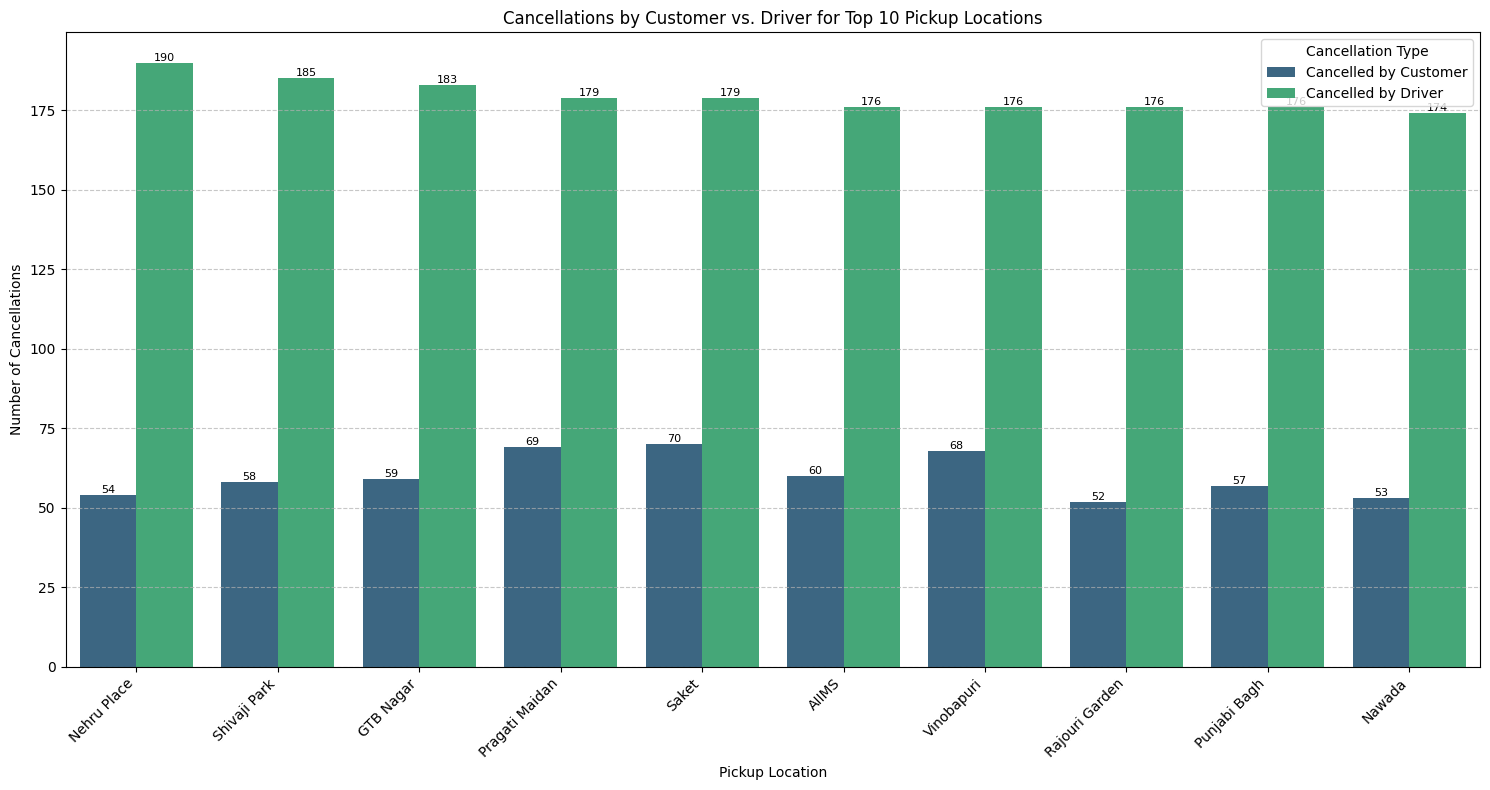

In [78]:
cancellation_counts_long = cancellation_counts_by_location.reset_index().melt(id_vars='Pickup Location', var_name='Cancellation Type', value_name='Count')

plt.figure(figsize=(15, 8))
ax = sns.barplot(data=cancellation_counts_long, x='Pickup Location', y='Count', hue='Cancellation Type', palette='viridis')
plt.title('Cancellations by Customer vs. Driver for Top 10 Pickup Locations')
plt.xlabel('Pickup Location')
plt.ylabel('Number of Cancellations')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Cancellation Type')
# Add values to the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=8)
plt.tight_layout()
plt.show()

In [82]:
print(df['Pickup Location'].unique())

['Palam Vihar' 'Shastri Nagar' 'Khandsa' 'Central Secretariat'
 'Ghitorni Village' 'AIIMS' 'Vaishali' 'Mayur Vihar' 'Noida Sector 62'
 'Rohini' 'Udyog Bhawan' 'Vidhan Sabha' 'Patel Chowk' 'Malviya Nagar'
 'Madipur' 'Jama Masjid' 'IGI Airport' 'Vinobapuri' 'Kashmere Gate'
 'Pitampura' 'Punjabi Bagh' 'Greater Noida' 'Tis Hazari' 'Noida Sector 18'
 'Kanhaiya Nagar' 'Okhla' 'Cyber Hub' 'Sadar Bazar Gurgaon' 'Shastri Park'
 'Faridabad Sector 15' 'Qutub Minar' 'Mundka' 'DLF City Court'
 'New Colony' 'Nirman Vihar' 'New Delhi Railway Station'
 'Civil Lines Gurgaon' 'Seelampur' 'Noida Extension' 'Adarsh Nagar'
 'Panipat' 'Karol Bagh' 'Sultanpur' 'Moti Nagar' 'Dilshad Garden'
 'Aya Nagar' 'Rajiv Chowk' 'MG Road' 'Jasola' 'Ardee City' 'Meerut'
 'Anand Vihar ISBT' 'Lajpat Nagar' 'Tughlakabad' 'Karkarduma' 'Dwarka Mor'
 'Anand Vihar' 'Uttam Nagar' 'Model Town' 'Mandi House' 'Ghitorni'
 'Rajiv Nagar' 'Sohna Road' 'Bahadurgarh' 'Moolchand' 'INA Market'
 'Sushant Lok' 'IIT Delhi' 'Satguru Ram Singh M

In [83]:
zone_mapping = {
    # North Delhi
    'Rohini': 'North Delhi',
    'Rohini West': 'North Delhi',
    'Rohini East': 'North Delhi',
    'Pitampura': 'North Delhi',
    'Shastri Nagar': 'North Delhi',
    'Adarsh Nagar': 'North Delhi',
    'Azadpur': 'North Delhi',
    'Model Town': 'North Delhi',
    'GTB Nagar': 'North Delhi',
    'Vishwavidyalaya': 'North Delhi',
    'Jahangirpuri': 'North Delhi',
    'Samaypur Badli': 'North Delhi',
    'Rithala': 'North Delhi',
    'Kanhaiya Nagar': 'North Delhi',
    'Keshav Puram': 'North Delhi',
    'Netaji Subhash Place': 'North Delhi',
    'Ashok Vihar': 'North Delhi',
    'Inderlok': 'North Delhi',
    'Pulbangash': 'North Delhi',

    # South Delhi
    'Saket': 'South Delhi',
    'Saket A Block': 'South Delhi',
    'Malviya Nagar': 'South Delhi',
    'Hauz Khas': 'South Delhi',
    'Green Park': 'South Delhi',
    'Qutub Minar': 'South Delhi',
    'Mehrauli': 'South Delhi',
    'Vasant Kunj': 'South Delhi',
    'Munirka': 'South Delhi',
    'RK Puram': 'South Delhi',
    'IIT Delhi': 'South Delhi',
    'Chhatarpur': 'South Delhi',
    'Sultanpur': 'South Delhi',
    'Ghitorni': 'South Delhi',
    'Ghitorni Village': 'South Delhi',
    'Aya Nagar': 'South Delhi',
    'Maidan Garhi': 'South Delhi',
    'Saidulajab': 'South Delhi',
    'Arjangarh': 'South Delhi',
    'Chirag Delhi': 'South Delhi',
    'Govindpuri': 'South Delhi',
    'Kalkaji': 'South Delhi',
    'Nehru Place': 'South Delhi',
    'Greater Kailash': 'South Delhi',
    'Panchsheel Park': 'South Delhi',
    'South Extension': 'South Delhi',
    'Lajpat Nagar': 'South Delhi',
    'INA Market': 'South Delhi',
    'Sarojini Nagar': 'South Delhi',
    'IGNOU Road': 'South Delhi',
    'Moolchand': 'South Delhi',
    'Badarpur': 'South Delhi',
    'Tughlakabad': 'South Delhi',
    'Jasola': 'South Delhi',
    'Okhla': 'South Delhi',
    'Bhikaji Cama Place': 'South Delhi',

    # Central Delhi
    'Connaught Place': 'Central Delhi',
    'Rajiv Chowk': 'Central Delhi',
    'Karol Bagh': 'Central Delhi',
    'Barakhamba Road': 'Central Delhi',
    'Mandi House': 'Central Delhi',
    'Central Secretariat': 'Central Delhi',
    'Udyog Bhawan': 'Central Delhi',
    'Patel Chowk': 'Central Delhi',
    'Lok Kalyan Marg': 'Central Delhi',
    'Jor Bagh': 'Central Delhi',
    'Khan Market': 'Central Delhi',
    'India Gate': 'Central Delhi',
    'Chanakyapuri': 'Central Delhi',
    'Pragati Maidan': 'Central Delhi',
    'ITO': 'Central Delhi',
    'Indraprastha': 'Central Delhi',
    'Ashram': 'Central Delhi',
    'Moti Nagar': 'Central Delhi',
    'Paharganj': 'Central Delhi',
    'New Delhi Railway Station': 'Central Delhi',
    'Delhi Gate': 'Central Delhi',
    'Chandni Chowk': 'Central Delhi',
    'Jama Masjid': 'Central Delhi',
    'Lal Quila': 'Central Delhi',
    'Kashmere Gate': 'Central Delhi',
    'Kashmere Gate ISBT': 'Central Delhi',
    'Tis Hazari': 'Central Delhi',
    'Sadar Bazar Gurgaon': 'Central Delhi',
    'Vidhan Sabha': 'Central Delhi',
    'Civil Lines Gurgaon': 'Central Delhi',
    'AIIMS': 'Central Delhi',

    # West Delhi
    'Janakpuri': 'West Delhi',
    'Dwarka Mor': 'West Delhi',
    'Dwarka Sector 21': 'West Delhi',
    'Uttam Nagar': 'West Delhi',
    'Nawada': 'West Delhi',
    'Tilak Nagar': 'West Delhi',
    'Rajouri Garden': 'West Delhi',
    'Punjabi Bagh': 'West Delhi',
    'Paschim Vihar': 'West Delhi',
    'Peeragarhi': 'West Delhi',
    'Mundka': 'West Delhi',
    'Tagore Garden': 'West Delhi',
    'Ramesh Nagar': 'West Delhi',
    'Madipur': 'West Delhi',
    'Kirti Nagar': 'West Delhi',
    'Subhash Nagar': 'West Delhi',
    'Ashok Park Main': 'West Delhi',
    'Shivaji Park': 'West Delhi',
    'Satguru Ram Singh Marg': 'West Delhi',

    # East Delhi
    'Laxmi Nagar': 'East Delhi',
    'Nirman Vihar': 'East Delhi',
    'Preet Vihar': 'East Delhi',
    'Mayur Vihar': 'East Delhi',
    'Akshardham': 'East Delhi',
    'Yamuna Bank': 'East Delhi',
    'Karkarduma': 'East Delhi',
    'Anand Vihar': 'East Delhi',
    'Anand Vihar ISBT': 'East Delhi',
    'Shahdara': 'East Delhi',
    'Shastri Park': 'East Delhi',
    'Seelampur': 'East Delhi',
    'Dilshad Garden': 'East Delhi',
    'Jhilmil': 'East Delhi',
    'Mansarovar Park': 'East Delhi',
    'Welcome': 'East Delhi',
    'Vinobapuri': 'East Delhi',
    'Sarai Kale Khan': 'East Delhi',

    # Gurgaon
    'Cyber Hub': 'Gurgaon',
    'MG Road': 'Gurgaon',
    'IFFCO Chowk': 'Gurgaon',
    'Sikanderpur': 'Gurgaon',
    'Huda City Centre': 'Gurgaon',
    'DLF Phase 3': 'Gurgaon',
    'DLF City Court': 'Gurgaon',
    'Golf Course Road': 'Gurgaon',
    'Gurgaon Sector 56': 'Gurgaon',
    'Gurgaon Sector 29': 'Gurgaon',
    'Sohna Road': 'Gurgaon',
    'Sushant Lok': 'Gurgaon',
    'Udyog Vihar': 'Gurgaon',
    'Udyog Vihar Phase 4': 'Gurgaon',
    'Ambience Mall': 'Gurgaon',
    'Old Gurgaon': 'Gurgaon',
    'Ardee City': 'Gurgaon',
    'Vatika Chowk': 'Gurgaon',
    'Gurgaon Railway Station': 'Gurgaon',
    'Hero Honda Chowk': 'Gurgaon',
    'Palam Vihar': 'Gurgaon',
    'New Colony': 'Gurgaon',
    'Rajiv Nagar': 'Gurgaon',
    'Subhash Chowk': 'Gurgaon',
    'Narsinghpur': 'Gurgaon',
    'Kherki Daula Toll': 'Gurgaon',
    'Basai Dhankot': 'Gurgaon',
    'Gwal Pahari': 'Gurgaon',
    'Badshahpur': 'Gurgaon',
    'Kadarpur': 'Gurgaon',

    # Noida
    'Noida Sector 18': 'Noida',
    'Noida Sector 62': 'Noida',
    'Noida Extension': 'Noida',
    'Noida Film City': 'Noida',
    'Botanical Garden': 'Noida',
    'Vaishali': 'Noida',
    'Kaushambi': 'Noida',
    'Indirapuram': 'Noida',

    # Greater Noida
    'Greater Noida': 'Greater Noida',

    # Faridabad
    'Faridabad Sector 15': 'Faridabad',
    'Tughlakabad': 'Faridabad',

    # NCR Outskirts
    'IGI Airport': 'NCR Outskirts',
    'Bahadurgarh': 'NCR Outskirts',
    'Manesar': 'NCR Outskirts',
    'IMT Manesar': 'NCR Outskirts',
    'Bhiwadi': 'NCR Outskirts',
    'Pataudi Chowk': 'NCR Outskirts',
    'Raj Nagar Extension': 'NCR Outskirts',
    'Ghaziabad': 'NCR Outskirts',
    'Khandsa': 'NCR Outskirts',
    'Hauz Rani': 'NCR Outskirts',

    # Out of NCR
    'Panipat': 'Out of NCR',
    'Sonipat': 'Out of NCR',
    'Meerut': 'Out of NCR',
}

# Apply mapping
df['Zone'] = df['Pickup Location'].map(zone_mapping)

In [85]:
df['Zone'].isna().sum()

np.int64(0)

In [86]:
df['Zone'].value_counts()

,count
Zone,
South Delhi,29719
Central Delhi,26527
Gurgaon,25454
West Delhi,16378
North Delhi,16374
East Delhi,15069
NCR Outskirts,8595
Noida,6784
Out of NCR,2534


In [87]:
df.to_csv("uber_dataset_final.csv",index=False)

In [88]:
from google.colab import files
files.download('uber_dataset_final.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>